In [ ]:
!ls /kaggle/input/datasets/dravyareddy/brats-2023

In [ ]:
data_dir = "/kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

In [ ]:
import os

cases = os.listdir(data_dir)
print("Total cases:", len(cases))
print("Sample case:", cases[0])

sample_path = os.path.join(data_dir, cases[0])
print("Files inside sample case:")
print(os.listdir(sample_path))

In [ ]:
import os

train_path = "/kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

cases = os.listdir(train_path)

print("Total patient cases:", len(cases))
print("First 5 cases:", cases[:5])

In [ ]:
import os

base_path = "/kaggle/input/datasets/dravyareddy/brats-2023"

train_folder = "ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

level1 = os.path.join(base_path, train_folder)

print("Inside Level 1:", os.listdir(level1))

# Go one more level down
level2 = os.path.join(level1, os.listdir(level1)[0])

cases = os.listdir(level2)

print("Total training cases:", len(cases))
print("First 5 cases:", cases[:5])

In [ ]:
import os

base = "/kaggle/input/datasets/dravyareddy/brats-2023"

# Go into TrainingData
base = os.path.join(base, "ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData")

# Skip nested folder automatically
while len(os.listdir(base)) == 1:
    base = os.path.join(base, os.listdir(base)[0])

print("Final path:", base)
print("Total cases:", len(os.listdir(base)))

In [ ]:
!pip install -q monai nibabel

In [ ]:
import os

sample_case = cases[0]
print("Sample case path:", sample_case)

files = os.listdir(sample_case)
for f in files:
    print(f)

In [ ]:
!pip uninstall -y torch torchvision torchaudio monai -q

In [ ]:
!pip install torch==2.1.2 torchvision==0.16.2 torchaudio==2.1.2 --index-url https://download.pytorch.org/whl/cu118 -q
!pip install monai==1.3.0 -q

In [ ]:
# 🔥 CLEAN ENV
!pip uninstall -y torch torchvision torchaudio monai -q

# 🔥 INSTALL P100-COMPATIBLE TORCH (AVAILABLE ON KAGGLE)
!pip install torch==2.2.2+cu118 torchvision==0.17.2+cu118 torchaudio==2.2.2+cu118 \
    --index-url https://download.pytorch.org/whl/cu118 -q

# 🔥 INSTALL MONAI (COMPATIBLE)
!pip install monai==1.3.0 -q

In [ ]:
!pip install torch==2.2.2+cu118 torchvision==0.17.2+cu118 torchaudio==2.2.2+cu118 \
    --index-url https://download.pytorch.org/whl/cu118 -q

!pip install monai==1.3.0 -q

In [ ]:
# 🔥 CLEAN AGAIN
!pip uninstall -y torch torchvision torchaudio monai numpy -q

# 🔥 INSTALL CORRECT NUMPY FIRST (VERY IMPORTANT)
!pip install numpy==1.26.4 -q

# 🔥 INSTALL P100-COMPATIBLE TORCH
!pip install torch==2.2.2+cu118 torchvision==0.17.2+cu118 torchaudio==2.2.2+cu118 \
    --index-url https://download.pytorch.org/whl/cu118 -q

# 🔥 INSTALL MONAI (STABLE VERSION)
!pip install monai==1.3.0 -q

In [ ]:
pip install numpy

In [ ]:
import torch, monai, numpy as np

print("Torch:", torch.__version__)
print("MONAI:", monai.__version__)
print("NumPy:", np.__version__)
print("GPU:", torch.cuda.get_device_name(0))

In [ ]:
!pip uninstall -y monai -q
!rm -rf /usr/local/lib/python3.12/dist-packages/monai*

In [ ]:
!pip install monai==1.4.0 --no-cache-dir -q

In [1]:
import monai
print(monai.__version__)

2026-05-01 09:35:25.262507: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777628125.298818    1038 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777628125.308303    1038 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777628125.360229    1038 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777628125.360258    1038 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777628125.360261    1038 computation_placer.cc:177] computation placer alr

1.4.0


In [26]:
# =============================
# 🔥 0. SETUP (RUN FIRST CELL)
# =============================
!pip install -q "numpy<2"
!pip install -q monai==1.3.0 nibabel

import os
os.environ["MONAI_USE_META_DICT"] = "0"

In [ ]:


# =============================
# 🔥 1. IMPORTS
# =============================
import torch
import numpy as np
from glob import glob
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Orientationd, NormalizeIntensityd,
    CropForegroundd, RandCropByPosNegLabeld,
    ToTensord
)
from monai.data import CacheDataset, DataLoader
from monai.networks.nets import SwinUNETR
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.transforms import AsDiscrete

# =============================
# 🔥 2. DEVICE
# =============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =============================
# 🔥 3. LOAD DATA
# =============================
train_path = "/kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

cases = sorted(glob(os.path.join(train_path, "*")))

def get_file(case, keyword):
    for f in os.listdir(case):
        if keyword in f and (f.endswith(".nii") or f.endswith(".nii.gz")):
            path = os.path.join(case, f)
            if os.path.getsize(path) > 0:
                return path
    return None

data = []
for case in cases:
    flair = get_file(case, "t2f")
    t1    = get_file(case, "t1n")
    t1ce  = get_file(case, "t1c")
    t2    = get_file(case, "t2w")
    seg   = get_file(case, "seg")

    if None not in [flair, t1, t1ce, t2, seg]:
        data.append({
            "image": [flair, t1, t1ce, t2],
            "label": seg
        })

print("Valid cases:", len(data))

# 🔥 USE SUBSET (faster + stable)
data = data[:100]

train_files, val_files = train_test_split(data, test_size=0.2, random_state=42)

# =============================
# 🔥 4. TRANSFORMS
# =============================
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(96, 96, 96),   # 🔥 bigger context → better learning
        pos=1,
        neg=1,
        num_samples=1,
    ),
    ToTensord(keys=["image", "label"])
])

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    ToTensord(keys=["image", "label"])
])

# =============================
# 🔥 5. DATASETS
# =============================
train_ds = CacheDataset(train_files, train_transforms, cache_rate=1.0, num_workers=2)
val_ds   = CacheDataset(val_files, val_transforms, cache_rate=1.0, num_workers=2)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=1, num_workers=2, pin_memory=True)

# =============================
# 🔥 6. MODEL (OPTIMIZED)
# =============================
model = SwinUNETR(
    img_size=(96,96,96),
    in_channels=4,
    out_channels=4,
    feature_size=12,   # 🔥 KEY CHANGE (stable on P100)
    spatial_dims=3
).to(device)

print("Model loaded")

# =============================
# 🔥 7. LOSS + OPTIMIZER
# =============================
loss_function = DiceCELoss(
    to_onehot_y=True,
    softmax=True,
    include_background=False
)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

dice_metric = DiceMetric(include_background=False, reduction="mean")

post_pred  = AsDiscrete(argmax=True, to_onehot=4)
post_label = AsDiscrete(to_onehot=4)

# =============================
# 🔥 8. TRAINING
# =============================
best_dice = 0
max_epochs = 50

for epoch in range(max_epochs):
    print(f"\nEpoch {epoch+1}/{max_epochs}")
    model.train()
    epoch_loss = 0

    for batch in train_loader:
        inputs = batch["image"].to(device).float()
        labels = batch["label"].to(device).long()

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    scheduler.step()
    print("Train Loss:", epoch_loss / len(train_loader))

    # =============================
    # 🔥 VALIDATION
    # =============================
    if (epoch + 1) % 5 == 0:
        model.eval()
        dice_metric.reset()

        with torch.no_grad():
            for val in val_loader:
                val_inputs = val["image"].to(device).float()
                val_labels = val["label"].to(device).long()

                val_outputs = sliding_window_inference(
                    val_inputs,
                    roi_size=(96,96,96),
                    sw_batch_size=2,
                    predictor=model
                )

                val_outputs = [post_pred(i) for i in val_outputs]
                val_labels  = [post_label(i) for i in val_labels]

                dice_metric(y_pred=val_outputs, y=val_labels)

        mean_dice = dice_metric.aggregate().item()
        dice_metric.reset()

        print("Val Dice:", mean_dice)

        if mean_dice > best_dice:
            best_dice = mean_dice
            torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
            print("🔥 Saved best model")

print("Final Best Dice:", best_dice)

In [18]:
import os

print(os.listdir())

['.virtual_documents', 'best_model.pth', 'swin_unetr_final.pth']


In [6]:
import os

case = "/kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00005-000"

print(os.listdir(case))

['BraTS-GLI-00005-000-seg.nii', 'BraTS-GLI-00005-000-t2w.nii', 'BraTS-GLI-00005-000-t2f.nii', 'BraTS-GLI-00005-000-t1c.nii', 'BraTS-GLI-00005-000-t1n.nii']


In [10]:
case_path = "/kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00005-000"

data_dict = load_case(case_path)
print(data_dict)

{'image': ['/kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00005-000/BraTS-GLI-00005-000-t2f.nii', '/kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00005-000/BraTS-GLI-00005-000-t1n.nii', '/kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00005-000/BraTS-GLI-00005-000-t1c.nii', '/kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00005-000/BraTS-GLI-00005-000-t2w.nii']}


Using case: /kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00014-001
✅ Model loaded
✅ Inference done


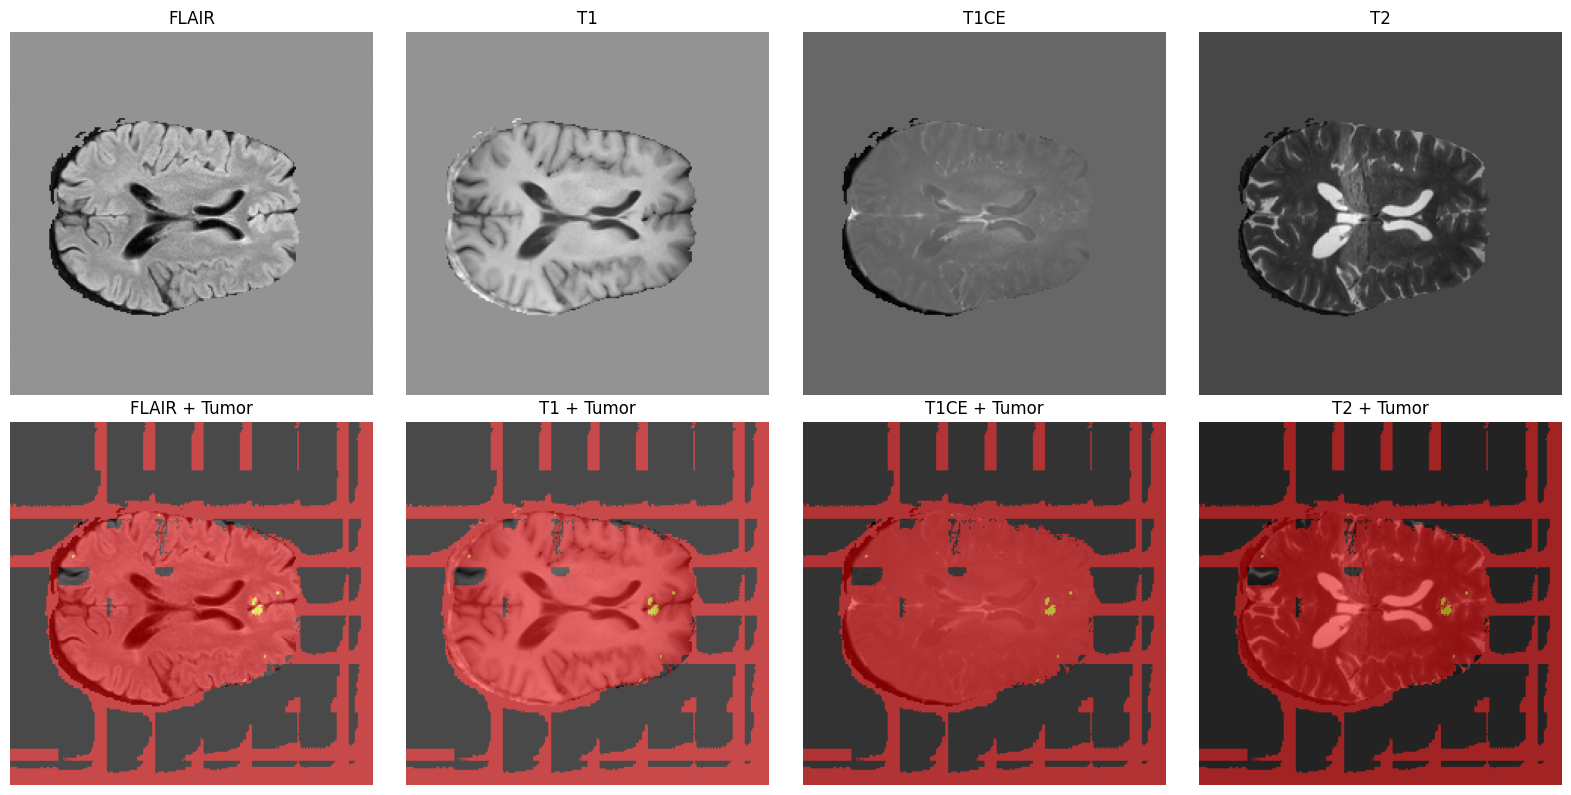

In [25]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from scipy.ndimage import label

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Orientationd, NormalizeIntensityd, ToTensord
)
from monai.inferers import sliding_window_inference
from monai.networks.nets import SwinUNETR

# -------------------------
# DEVICE
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# SELECT CASE
# -------------------------
base_path = "/kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

cases = sorted(glob(os.path.join(base_path, "*")))

def get_case(index=0):
    return cases[index]

case_path = get_case(12)   # 🔥 change index for different patient
print("Using case:", case_path)

# -------------------------
# LOAD FILES
# -------------------------
def load_case(case_path):
    files = os.listdir(case_path)

    def find(keyword):
        for f in files:
            full = os.path.join(case_path, f)
            if keyword in f and (f.endswith(".nii") or f.endswith(".nii.gz")):
                if os.path.getsize(full) > 0:
                    return full
        raise ValueError(f"{keyword} missing")

    return {
        "image": [
            find("t2f"),  # FLAIR
            find("t1n"),  # T1
            find("t1c"),  # T1CE
            find("t2w"),  # T2
        ]
    }

data_dict = load_case(case_path)

# -------------------------
# MODEL
# -------------------------
model = SwinUNETR(
    img_size=(64,64,64),
    in_channels=4,
    out_channels=4,
    feature_size=24,
    spatial_dims=3
).to(device)

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

print("✅ Model loaded")

# -------------------------
# TRANSFORMS
# -------------------------
transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys="image"),
    Orientationd(keys="image", axcodes="RAS"),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    ToTensord(keys="image")
])

data = transforms(data_dict)

image = data["image"]
if hasattr(image, "as_tensor"):
    image = image.as_tensor()

image = image.unsqueeze(0).to(device).float()

# -------------------------
# INFERENCE
# -------------------------
with torch.no_grad():
    logits = sliding_window_inference(
        image,
        roi_size=(64,64,64),
        sw_batch_size=1,
        predictor=model,
        overlap=0.5
    )

# 🔥 IMPORTANT: use softmax (not raw argmax)
probs = torch.softmax(logits, dim=1)
pred = probs.argmax(dim=1).cpu().numpy()[0]

print("✅ Inference done")

# -------------------------
# 🔥 REMOVE NOISE (CRITICAL FIX)
# -------------------------
def remove_small_regions(mask, min_size=1000):
    labeled, num = label(mask)
    output = np.zeros_like(mask)
    for i in range(1, num+1):
        region = (labeled == i)
        if region.sum() > min_size:
            output[region] = 1
    return output

wt = remove_small_regions(pred > 0)
tc = remove_small_regions(np.logical_or(pred == 1, pred == 3))
et = remove_small_regions(pred == 3)

# -------------------------
# VISUALIZATION
# -------------------------
slice_idx = image.shape[-1] // 2

flair = image.cpu().numpy()[0,0]
t1    = image.cpu().numpy()[0,1]
t1ce  = image.cpu().numpy()[0,2]
t2    = image.cpu().numpy()[0,3]

# RGB overlay
overlay = np.zeros((flair.shape[0], flair.shape[1], 3))

# Yellow = Whole tumor
overlay[wt[:,:,slice_idx]] = [1,1,0]

# Red = Tumor core
overlay[tc[:,:,slice_idx]] = [1,0,0]

# Green = Enhancing tumor
overlay[et[:,:,slice_idx]] = [0,1,0]

plt.figure(figsize=(16,8))

titles = ["FLAIR", "T1", "T1CE", "T2"]
images = [flair, t1, t1ce, t2]

for i in range(4):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i][:,:,slice_idx], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

    plt.subplot(2,4,i+5)
    plt.imshow(images[i][:,:,slice_idx], cmap="gray")
    plt.imshow(overlay, alpha=0.5)
    plt.title(titles[i] + " + Tumor")
    plt.axis("off")

plt.tight_layout()
plt.show()